### Working Station

In [ ]:
import os
import pyspark

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PySpark:", pyspark.__version__)

JAVA_HOME: /opt/java-home
PySpark: 3.5.1


In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NotebookPySpark")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)

print("Spark:", spark.version)
print("Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/21 05:03:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/21 05:03:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/09/21 05:03:36 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Spark: 3.5.1
Java: 17.0.20.1


In [4]:
mydir = "/opt/app/working_dir/"

### Spark ML

Construiremos un modelo desde cero. Usaremos regresión para estimar los puntos (PTS) de un jugador en un partido.

Primero haremos una versión sencilla con variables numéricas. Después podremos agregar posición, pipelines, otros algoritmos y ajuste de hiperparámetros.

In [6]:
nba = spark.read.csv( 
  header = True, 
  inferSchema = True, 
  path = mydir + 'nba/games_details.csv' 
  ) 
nba.printSchema()

[Stage 1:=======>                                                   (1 + 7) / 8]

root
 |-- GAME_ID: integer (nullable = true)
 |-- TEAM_ID: integer (nullable = true)
 |-- TEAM_ABBREVIATION: string (nullable = true)
 |-- TEAM_CITY: string (nullable = true)
 |-- PLAYER_ID: integer (nullable = true)
 |-- PLAYER_NAME: string (nullable = true)
 |-- START_POSITION: string (nullable = true)
 |-- COMMENT: string (nullable = true)
 |-- MIN: string (nullable = true)
 |-- FGM: double (nullable = true)
 |-- FGA: double (nullable = true)
 |-- FG_PCT: double (nullable = true)
 |-- FG3M: double (nullable = true)
 |-- FG3A: double (nullable = true)
 |-- FG3_PCT: double (nullable = true)
 |-- FTM: double (nullable = true)
 |-- FTA: double (nullable = true)
 |-- FT_PCT: double (nullable = true)
 |-- OREB: double (nullable = true)
 |-- DREB: double (nullable = true)
 |-- REB: double (nullable = true)
 |-- AST: double (nullable = true)
 |-- STL: double (nullable = true)
 |-- BLK: double (nullable = true)
 |-- TO: double (nullable = true)
 |-- PF: double (nullable = true)
 |-- PTS: dou

In [7]:
nba.show()

26/09/21 05:04:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+----------+-----------------+------------+---------+------------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
| GAME_ID|   TEAM_ID|TEAM_ABBREVIATION|   TEAM_CITY|PLAYER_ID|       PLAYER_NAME|START_POSITION|COMMENT|  MIN| FGM| FGA|FG_PCT|FG3M|FG3A|FG3_PCT|FTM| FTA|FT_PCT|OREB|DREB|REB| AST|STL|BLK| TO| PF| PTS|PLUS_MINUS|
+--------+----------+-----------------+------------+---------+------------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
|42000102|1610612764|              WAS|  Washington|   203078|      Bradley Beal|             F|   NULL|34:36|14.0|28.0|   0.5| 1.0| 6.0|  0.167|4.0| 6.0| 0.667| 0.0| 4.0|4.0| 3.0|1.0|0.0|1.0|0.0|33.0|     -22.0|
|42000102|1610612764|              WAS|  Washington|  1629060|     Rui Hachimura|             F|   NULL|25:50| 4.0| 6.0| 0.667| 1.0| 1.0|    1.0|2.0

In [8]:
### Seleccionamos las variables
from pyspark.sql import functions as f

# Variables que utilizaremos para estimar los puntos del jugador
feature_columns = [
    "minutes",
    "FGA",   # Tiros de campo intentados
    "FG3A",  # Triples intentados
    "FTA",   # Tiros libres intentados
    "OREB",  # Rebotes ofensivos
    "DREB",  # Rebotes defensivos
    "AST",   # Asistencias
    "STL",   # Robos
    "BLK",   # Bloqueos
    "TO",    # Pérdidas de balón
    "PF"     # Faltas personales
]

# Variable que queremos estimar
label_column = "PTS"

OJO: No incluimos FGM, FG3M ni FTM porque los puntos pueden calcularse directamente con esas variables. Incluirlas provocaría fuga de información (data leakage).

In [9]:
nba_ml = nba.withColumn(
    "minutes",
    f.regexp_extract(f.col("MIN"), r"^(\d+)", 1).cast("double")
)

In [11]:
nba_ml.select("PLAYER_NAME", "MIN", "minutes").show(10)

+------------------+-----+-------+
|       PLAYER_NAME|  MIN|minutes|
+------------------+-----+-------+
|      Bradley Beal|34:36|   34.0|
|     Rui Hachimura|25:50|   25.0|
|          Alex Len|12:11|   12.0|
|         Raul Neto|19:19|   19.0|
| Russell Westbrook|29:07|   29.0|
|     Davis Bertans|23:43|   23.0|
|         Ish Smith|23:20|   23.0|
|    Daniel Gafford|20:00|   20.0|
|Chandler Hutchison|16:29|   16.0|
|       Robin Lopez|10:15|   10.0|
+------------------+-----+-------+
only showing top 10 rows



### Nos quedamos con nuestro dataset:

In [13]:
nba_ml = nba_ml.select(
    "PLAYER_NAME",
    *feature_columns,
    label_column
)

nba_ml.show(10)

+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|       PLAYER_NAME|minutes| FGA|FG3A| FTA|OREB|DREB| AST|STL|BLK| TO| PF| PTS|
+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|      Bradley Beal|   34.0|28.0| 6.0| 6.0| 0.0| 4.0| 3.0|1.0|0.0|1.0|0.0|33.0|
|     Rui Hachimura|   25.0| 6.0| 1.0| 3.0| 2.0| 5.0| 1.0|0.0|0.0|3.0|4.0|11.0|
|          Alex Len|   12.0| 5.0| 0.0| 0.0| 3.0| 2.0| 0.0|1.0|0.0|0.0|2.0| 6.0|
|         Raul Neto|   19.0| 5.0| 2.0| 0.0| 1.0| 2.0| 1.0|0.0|0.0|0.0|2.0| 4.0|
| Russell Westbrook|   29.0|10.0| 3.0|10.0| 2.0| 4.0|11.0|0.0|0.0|4.0|0.0|10.0|
|     Davis Bertans|   23.0| 4.0| 4.0| 0.0| 0.0| 2.0| 0.0|0.0|0.0|0.0|6.0| 0.0|
|         Ish Smith|   23.0|14.0| 2.0| 0.0| 0.0| 1.0| 3.0|0.0|0.0|1.0|1.0|10.0|
|    Daniel Gafford|   20.0| 4.0| 0.0| 9.0| 4.0| 2.0| 1.0|1.0|1.0|1.0|1.0|11.0|
|Chandler Hutchison|   16.0| 4.0| 0.0| 2.0| 0.0| 2.0| 1.0|0.0|0.0|1.0|1.0| 4.0|
|       Robin Lopez|   10.0| 3.0| 0.0| 0

#### Eliminar registros incompletos - 
Algunos jugadores aparecen registrados, pero no participaron en el partido. 
######
Esas filas pueden tener valores nulos en MIN, PTS y otras estadísticas.

In [14]:
print("Filas antes de la limpieza:", nba_ml.count())

nba_ml = nba_ml.dropna(
    subset=feature_columns + [label_column]
)

print("Filas después de la limpieza:", nba_ml.count())

Filas antes de la limpieza: 615626


[Stage 9:======================>                                    (3 + 5) / 8]

Filas después de la limpieza: 515565


#### Y será que habrá jugadores sin minutos?

In [19]:
nba_ml.filter(f.col("minutes") <= 0).count()

5373

In [20]:
nba_ml = nba_ml.filter(f.col("minutes") > 0)

In [21]:
nba_ml.count()

510192

In [22]:
nba_ml.show()

+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|       PLAYER_NAME|minutes| FGA|FG3A| FTA|OREB|DREB| AST|STL|BLK| TO| PF| PTS|
+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|      Bradley Beal|   34.0|28.0| 6.0| 6.0| 0.0| 4.0| 3.0|1.0|0.0|1.0|0.0|33.0|
|     Rui Hachimura|   25.0| 6.0| 1.0| 3.0| 2.0| 5.0| 1.0|0.0|0.0|3.0|4.0|11.0|
|          Alex Len|   12.0| 5.0| 0.0| 0.0| 3.0| 2.0| 0.0|1.0|0.0|0.0|2.0| 6.0|
|         Raul Neto|   19.0| 5.0| 2.0| 0.0| 1.0| 2.0| 1.0|0.0|0.0|0.0|2.0| 4.0|
| Russell Westbrook|   29.0|10.0| 3.0|10.0| 2.0| 4.0|11.0|0.0|0.0|4.0|0.0|10.0|
|     Davis Bertans|   23.0| 4.0| 4.0| 0.0| 0.0| 2.0| 0.0|0.0|0.0|0.0|6.0| 0.0|
|         Ish Smith|   23.0|14.0| 2.0| 0.0| 0.0| 1.0| 3.0|0.0|0.0|1.0|1.0|10.0|
|    Daniel Gafford|   20.0| 4.0| 0.0| 9.0| 4.0| 2.0| 1.0|1.0|1.0|1.0|1.0|11.0|
|Chandler Hutchison|   16.0| 4.0| 0.0| 2.0| 0.0| 2.0| 1.0|0.0|0.0|1.0|1.0| 4.0|
|       Robin Lopez|   10.0| 3.0| 0.0| 0

In [23]:
nba_ml.printSchema()

root
 |-- PLAYER_NAME: string (nullable = true)
 |-- minutes: double (nullable = true)
 |-- FGA: double (nullable = true)
 |-- FG3A: double (nullable = true)
 |-- FTA: double (nullable = true)
 |-- OREB: double (nullable = true)
 |-- DREB: double (nullable = true)
 |-- AST: double (nullable = true)
 |-- STL: double (nullable = true)
 |-- BLK: double (nullable = true)
 |-- TO: double (nullable = true)
 |-- PF: double (nullable = true)
 |-- PTS: double (nullable = true)



### Resumen estadístico

In [26]:
nba_ml.select(
    *feature_columns,
    label_column
).summary().show(vertical=True)

[Stage 28:==============>                                           (2 + 6) / 8]

-RECORD 0----------------------
 summary | count               
 minutes | 510192              
 FGA     | 510192              
 FG3A    | 510192              
 FTA     | 510192              
 OREB    | 510192              
 DREB    | 510192              
 AST     | 510192              
 STL     | 510192              
 BLK     | 510192              
 TO      | 510192              
 PF      | 510192              
 PTS     | 510192              
-RECORD 1----------------------
 summary | mean                
 minutes | 22.734105983629693  
 FGA     | 7.961432166713708   
 FG3A    | 2.120358610091887   
 FTA     | 2.3266691755260767  
 OREB    | 1.0409316492614544  
 DREB    | 3.057276476306959   
 AST     | 2.113073117571424   
 STL     | 0.7306719823125412  
 BLK     | 0.46707318029290934 
 TO      | 1.3405580644149653  
 PF      | 2.0320781196098725  
 PTS     | 9.744353106281556   
-RECORD 2----------------------
 summary | stddev              
 minutes | 11.072455681177132  
 FGA    

### Análisis exploratorio:

In [28]:
# Tomamos una muestra para visualizar los datos localmente.
# No utilizamos todo el dataset porque toPandas() lleva los datos
# desde Spark hasta la memoria de la computadora principal.

nba_sample = (
    nba_ml
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .limit(10000)
    .toPandas()
)

print("Filas utilizadas en las gráficas:", len(nba_sample))

Filas utilizadas en las gráficas: 10000


*(Nota: `pandas`, `pyarrow`, `matplotlib` y `seaborn` ya vienen preinstalados en la imagen del contenedor Docker)*

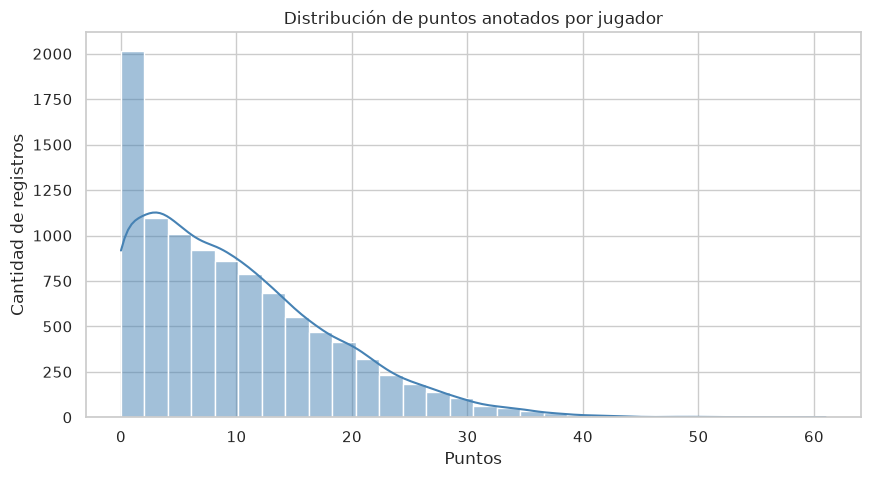

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(
    data=nba_sample,
    x="PTS",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribución de puntos anotados por jugador")
plt.xlabel("Puntos")
plt.ylabel("Cantidad de registros")
plt.show()

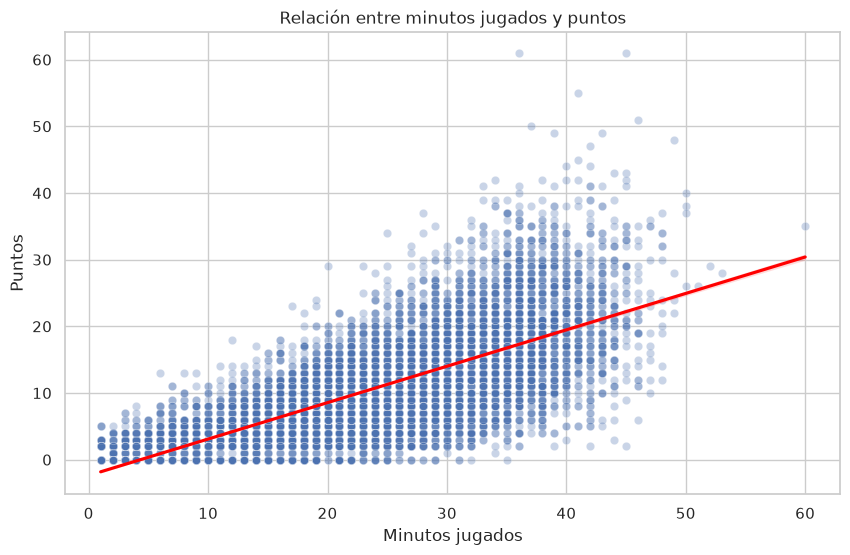

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=nba_sample,
    x="minutes",
    y="PTS",
    alpha=0.30
)

sns.regplot(
    data=nba_sample,
    x="minutes",
    y="PTS",
    scatter=False,
    color="red"
)

plt.title("Relación entre minutos jugados y puntos")
plt.xlabel("Minutos jugados")
plt.ylabel("Puntos")
plt.show()

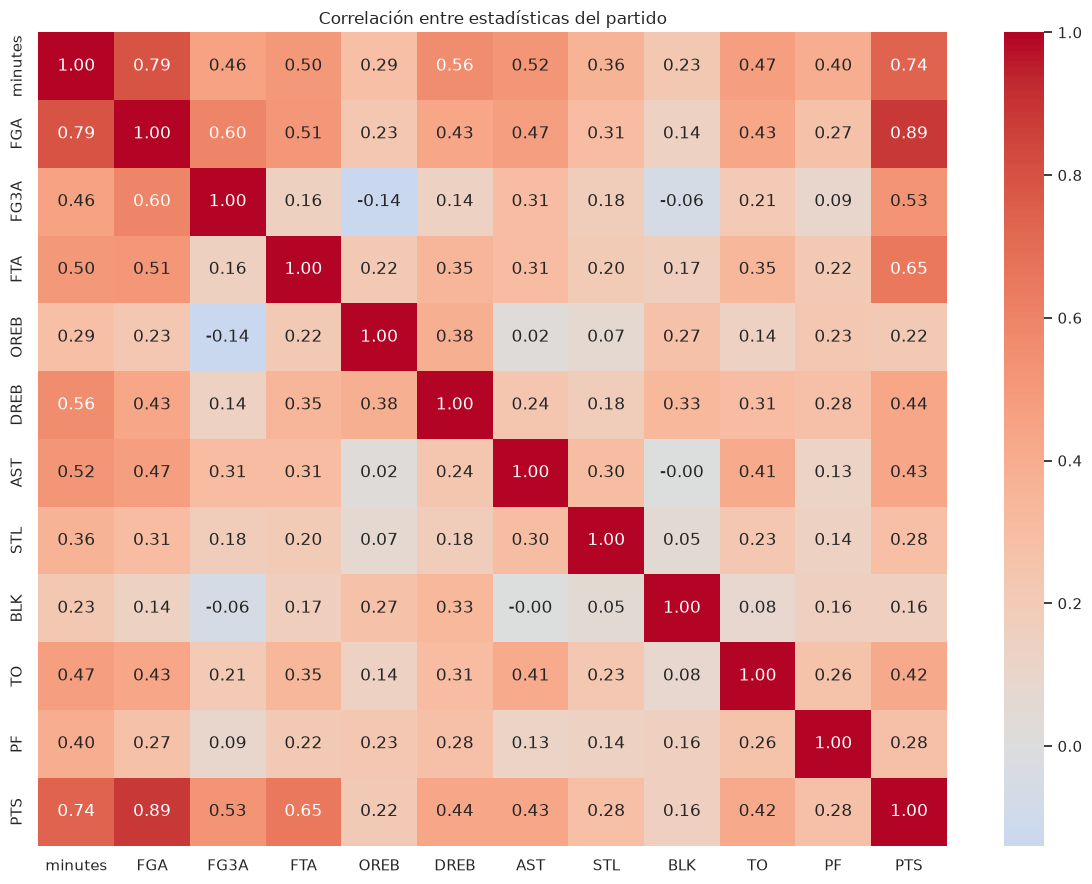

In [33]:
correlation_columns = feature_columns + [label_column]

correlation_matrix = (
    nba_sample[correlation_columns]
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre estadísticas del partido")
plt.tight_layout()
plt.show()

### Regresamos a Spark: Armar el modelo

In [35]:
from pyspark.ml.feature import VectorAssembler
# Spark necesita de un VectorAssembler para agarrar las variables necesarias para entrenar
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

nba_vectorized = assembler.transform(nba_ml)

In [36]:
nba_vectorized.select(
    "PLAYER_NAME",
    *feature_columns,
    "features",
    "PTS"
).show(5, truncate=False)

+-----------------+-------+----+----+----+----+----+----+---+---+---+---+-------------------------------------------------+----+
|PLAYER_NAME      |minutes|FGA |FG3A|FTA |OREB|DREB|AST |STL|BLK|TO |PF |features                                         |PTS |
+-----------------+-------+----+----+----+----+----+----+---+---+---+---+-------------------------------------------------+----+
|Bradley Beal     |34.0   |28.0|6.0 |6.0 |0.0 |4.0 |3.0 |1.0|0.0|1.0|0.0|[34.0,28.0,6.0,6.0,0.0,4.0,3.0,1.0,0.0,1.0,0.0]  |33.0|
|Rui Hachimura    |25.0   |6.0 |1.0 |3.0 |2.0 |5.0 |1.0 |0.0|0.0|3.0|4.0|[25.0,6.0,1.0,3.0,2.0,5.0,1.0,0.0,0.0,3.0,4.0]   |11.0|
|Alex Len         |12.0   |5.0 |0.0 |0.0 |3.0 |2.0 |0.0 |1.0|0.0|0.0|2.0|(11,[0,1,4,5,7,10],[12.0,5.0,3.0,2.0,1.0,2.0])   |6.0 |
|Raul Neto        |19.0   |5.0 |2.0 |0.0 |1.0 |2.0 |1.0 |0.0|0.0|0.0|2.0|[19.0,5.0,2.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,2.0]   |4.0 |
|Russell Westbrook|29.0   |10.0|3.0 |10.0|2.0 |4.0 |11.0|0.0|0.0|4.0|0.0|[29.0,10.0,3.0,10.0,2.0,

In [37]:
# Separamos el train y test
train_data, test_data = nba_vectorized.randomSplit(
    weights=[0.80, 0.20],
    seed=42
)

In [38]:
print("Registros de entrenamiento:", train_data.count())
print("Registros de prueba:", test_data.count())

Registros de entrenamiento: 408139


[Stage 37:===========================================>              (6 + 2) / 8]

Registros de prueba: 102053


### Entrenamos:

In [41]:
from pyspark.ml.regression import LinearRegression

In [42]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="PTS",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

| Parámetro         | Función                                        |
| ----------------- | ---------------------------------------------- |
| `featuresCol`     | Columna que contiene las variables predictoras |
| `labelCol`        | Variable que queremos estimar                  |
| `predictionCol`   | Columna donde se guardarán las predicciones    |
| `maxIter`         | Número máximo de iteraciones del algoritmo     |
| `regParam`        | Intensidad de la regularización                |
| `elasticNetParam` | Tipo de regularización                         |


In [44]:
# Entrenamos:
lr_model = lr.fit(train_data)

26/09/21 05:23:11 WARN Instrumentation: [954db182] regParam is zero, which might cause numerical instability and overfitting.
26/09/21 05:23:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/21 05:23:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/09/21 05:23:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

In [45]:
lr_model

LinearRegressionModel: uid=LinearRegression_3bdc0ed0ce6e, numFeatures=11

In [46]:
print("Intercepto:", lr_model.intercept)

for feature, coefficient in zip(
    feature_columns,
    lr_model.coefficients
):
    print(f"{feature:10s}: {coefficient:.4f}")

Intercepto: -0.7345374808574627
minutes   : 0.0158
FGA       : 0.9662
FG3A      : 0.2173
FTA       : 0.8007
OREB      : -0.1066
DREB      : 0.0664
AST       : -0.0477
STL       : -0.0027
BLK       : 0.1071
TO        : 0.0034
PF        : 0.0318


In [48]:
# PREDECIMOS
predictions_lr = lr_model.transform(test_data)

In [49]:
predictions_lr.select(
    "PLAYER_NAME",
    "minutes",
    "FGA",
    "FG3A",
    "FTA",
    "PTS",
    "prediction"
).show(20, truncate=False)

+------------+-------+----+----+---+----+------------------+
|PLAYER_NAME |minutes|FGA |FG3A|FTA|PTS |prediction        |
+------------+-------+----+----+---+----+------------------+
|Aaron Brooks|10.0   |5.0 |3.0 |2.0|5.0 |6.5740401551434475|
|Aaron Brooks|15.0   |8.0 |3.0 |0.0|2.0 |7.730776304887615 |
|Aaron Brooks|16.0   |6.0 |2.0 |0.0|9.0 |5.723648365308574 |
|Aaron Brooks|18.0   |7.0 |2.0 |0.0|2.0 |6.822345485976777 |
|Aaron Brooks|20.0   |9.0 |3.0 |2.0|13.0|10.6107202039375  |
|Aaron Brooks|22.0   |7.0 |4.0 |0.0|5.0 |7.311435104068722 |
|Aaron Brooks|24.0   |5.0 |2.0 |4.0|5.0 |8.146281964113786 |
|Aaron Brooks|25.0   |8.0 |3.0 |4.0|11.0|11.256354902626317|
|Aaron Brooks|28.0   |9.0 |2.0 |0.0|7.0 |8.645775287831878 |
|Aaron Brooks|29.0   |12.0|5.0 |2.0|23.0|14.004296907946543|
|Aaron Brooks|29.0   |13.0|7.0 |7.0|20.0|19.27510935074903 |
|Aaron Brooks|30.0   |10.0|4.0 |2.0|7.0 |11.80415265256525 |
|Aaron Brooks|30.0   |11.0|3.0 |6.0|14.0|15.86332452766042 |
|Aaron Brooks|31.0   |11

In [50]:
predictions_lr.select(
    "PLAYER_NAME",
    f.col("PTS").alias("Puntos_reales"),
    f.round("prediction", 2).alias("Puntos_estimados")
).show(20, truncate=False)

+------------+-------------+----------------+
|PLAYER_NAME |Puntos_reales|Puntos_estimados|
+------------+-------------+----------------+
|Aaron Brooks|5.0          |6.57            |
|Aaron Brooks|2.0          |7.73            |
|Aaron Brooks|9.0          |5.72            |
|Aaron Brooks|2.0          |6.82            |
|Aaron Brooks|13.0         |10.61           |
|Aaron Brooks|5.0          |7.31            |
|Aaron Brooks|5.0          |8.15            |
|Aaron Brooks|11.0         |11.26           |
|Aaron Brooks|7.0          |8.65            |
|Aaron Brooks|23.0         |14.0            |
|Aaron Brooks|20.0         |19.28           |
|Aaron Brooks|7.0          |11.8            |
|Aaron Brooks|14.0         |15.86           |
|Aaron Brooks|13.0         |12.97           |
|Aaron Brooks|13.0         |20.79           |
|Aaron Brooks|13.0         |15.64           |
|Aaron Brooks|13.0         |16.57           |
|Aaron Gordon|11.0         |12.48           |
|Aaron Gordon|17.0         |14.68 

In [53]:
# Métricas:
from pyspark.ml.evaluation import RegressionEvaluator
mae_evaluator = RegressionEvaluator(
    labelCol="PTS",
    predictionCol="prediction",
    metricName="mae"
)

mae = mae_evaluator.evaluate(predictions_lr)


rmse_evaluator = RegressionEvaluator(
    labelCol="PTS",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = rmse_evaluator.evaluate(predictions_lr)



r2_evaluator = RegressionEvaluator(
    labelCol="PTS",
    predictionCol="prediction",
    metricName="r2"
)

r2 = r2_evaluator.evaluate(predictions_lr)

In [55]:
print("Evaluación de la regresión lineal")
print("----------------------------------")
print(f"MAE : {mae:.4f} puntos")
print(f"RMSE: {rmse:.4f} puntos")
print(f"R²  : {r2:.4f}")

Evaluación de la regresión lineal
----------------------------------
MAE : 2.4338 puntos
RMSE: 3.2266 puntos
R²  : 0.8369


In [56]:
predictions_sample = (
    predictions_lr
    .select("PTS", "prediction")
    .limit(5000)
    .toPandas()
)

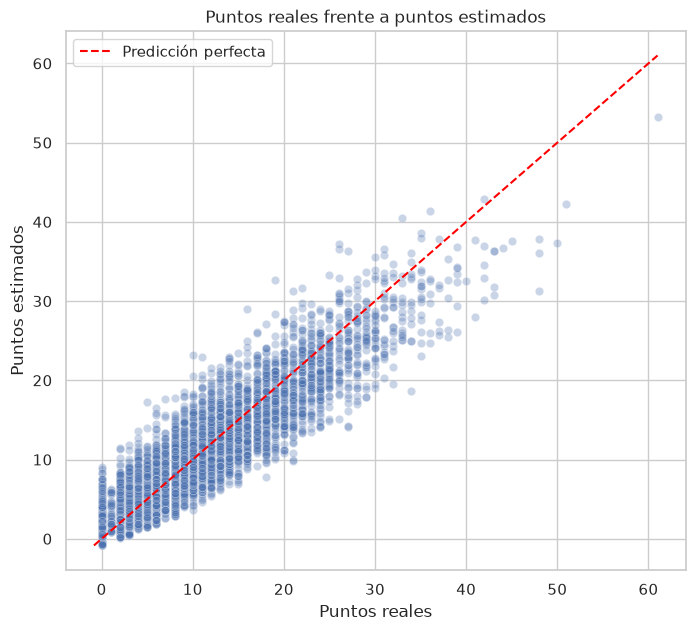

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=predictions_sample,
    x="PTS",
    y="prediction",
    alpha=0.30
)

# Línea que representa una predicción perfecta: y = x
minimum = min(
    predictions_sample["PTS"].min(),
    predictions_sample["prediction"].min()
)

maximum = max(
    predictions_sample["PTS"].max(),
    predictions_sample["prediction"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.title("Puntos reales frente a puntos estimados")
plt.xlabel("Puntos reales")
plt.ylabel("Puntos estimados")
plt.legend()
plt.show()

In [58]:
predictions_lr = predictions_lr.withColumn(
    "residual",
    f.col("PTS") - f.col("prediction")
)

In [59]:
predictions_lr.select(
    "PLAYER_NAME",
    "PTS",
    f.round("prediction", 2).alias("prediction"),
    f.round("residual", 2).alias("residual")
).orderBy(
    f.desc(f.abs("residual"))
).show(20, truncate=False)

[Stage 67:>                                                         (0 + 8) / 8]

+----------------+----+----------+--------+
|PLAYER_NAME     |PTS |prediction|residual|
+----------------+----+----------+--------+
|Stephen Curry   |38.0|20.7      |17.3    |
|Tracy McGrady   |51.0|33.79     |17.21   |
|Carmelo Anthony |62.0|44.8      |17.2    |
|Jaylen Brown    |40.0|23.12     |16.88   |
|Stephen Curry   |39.0|22.16     |16.84   |
|Allen Crabbe    |41.0|24.19     |16.81   |
|Bojan Bogdanovic|48.0|31.3      |16.7    |
|Damian Lillard  |49.0|32.31     |16.69   |
|Arron Afflalo   |38.0|21.43     |16.57   |
|Vince Carter    |48.0|31.86     |16.14   |
|Nemanja Bjelica |34.0|17.88     |16.12   |
|Justin Anderson |2.0 |18.1      |-16.1   |
|Donovan Mitchell|40.0|23.98     |16.02   |
|Kobe Bryant     |16.0|31.88     |-15.88  |
|Stephen Curry   |42.0|26.3      |15.7    |
|CJ Miles        |40.0|24.4      |15.6    |
|Stephen Jackson |7.0 |22.43     |-15.43  |
|Jayson Tatum    |41.0|25.58     |15.42   |
|Duncan Robinson |34.0|18.65     |15.35   |
|Terence Davis   |8.0 |23.3     

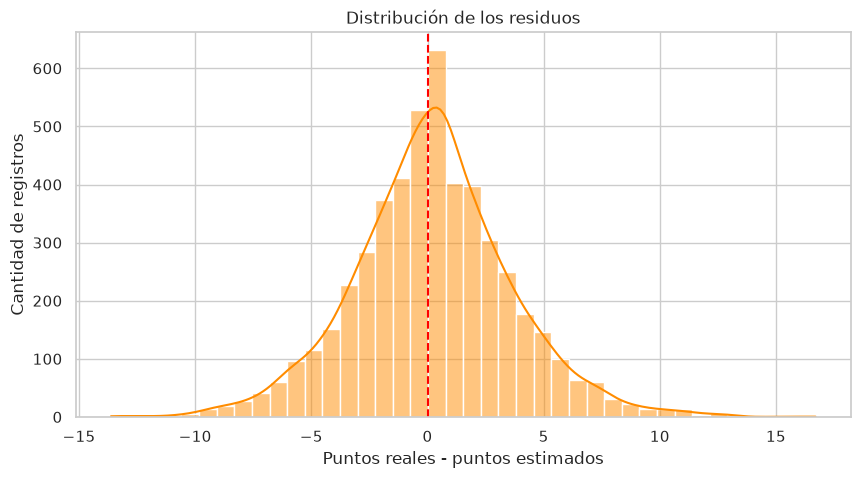

In [60]:
residuals_sample = (
    predictions_lr
    .select("residual")
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=residuals_sample,
    x="residual",
    bins=40,
    kde=True,
    color="darkorange"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Distribución de los residuos")
plt.xlabel("Puntos reales - puntos estimados")
plt.ylabel("Cantidad de registros")
plt.show()